# Stim-CODE Demo

## Prerequisites

Before running this notebook, please:

1. Clone the **Stim-CODE** repository (instructions provided below)  
2. Install the **GrOpt** toolbox for gradient waveform optimization  

---

## Stim-CODE Repository

- GitHub: https://github.com/ahannum/stim_code  

---

## GrOpt Installation
- Pre-release (v2.0.0): https://github.com/cmr-group/gropt-dev  

Follow the installation instructions in the GrOpt repository before running this notebook.

---

## References
**Stim-CODE**  
Hannum AJ, Loecher M, Chen Q, Arbes E, Setsompop K, Zaitsev M, Ennis DB. Stim-CODE: PNS and CNS constraint-optimized diffusion encoding for neuroimaging on 200 mT/m whole-body gradients. Magn Reson Med. In preparation.

**GrOpt**  
Loecher, M., Middione, M. J., & Ennis, D. B. (2020).  
*A gradient optimization toolbox for general purpose time-optimal MRI gradient waveform design (GrOpt).*  
Magnetic Resonance in Medicine, 84(6), 3234–3245.  
https://doi.org/10.1002/mrm.28384

In [2]:
!pip install --pre gropt==2.0.0.rc11


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import sys

# Detect Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !git clone https://github.com/ahannum/stim_code.git
    repo_path = "/content/stim_code"
    os.chdir(repo_path)
else:
    # assume notebook is already inside repo
    repo_path = os.getcwd()

print("Using repo path:", repo_path)



Using repo path: /Users/ariel/Documents/GitHub/stim_code/Examples


In [4]:

import gropt
from gropt.plot import plot_diff
from gropt.diff import diff_min_TE
import numpy as np
import sys
sys.path.append('../utils/')
from stim_code_utils import diff_min_TE_base, make_stim_envelope # My modified version of diff_min_TE 
from trap_diffusion import *
from plot_utils import *
import os


In [ ]:
# First define some common params across all examples
# Here we are simulating a 1.5 x 1.5 x 1.5 isotropic resolution with 6/8 PF and GRAPPA x 2
base_params = {
    'T_90': 2.835e-3,  # Duration of the 90° RF pulse [s]
    'T_180': 7.07e-3,  # Duration of the 180° RF pulse [s]
    'T_180_center': 0.00354075, # Center of the 180° RF pulse relative to its start [s]
    'T_readout': 13.734e-3,  # [s]
    'gmax': .190,  # Maximum gradient amplitude [T/m]
    'smax': 200,  # Maximum gradient slewrate [T/m/s]
    'MMT': 1,  # Moment order to null up to, so 2 = M0+M1+M2 nulling, 1 = M0+M1, 0 = M0
    'dt': 250e-6,  # Gradient waveform step size [s]
    'bvalue': 1000,  # Diffusion weighting [s/mm^2]
    }


# We can generate random safe parameters for PNs and CNS
safe, safe_cardiac = gropt.get_random_safe_params()

# For CNS typically all 3 axis have the same time constants so we adjust the output to take the mean across all 3 to be the same
def infer_decimals(arr):
    """Infer max number of decimal places from array values."""
    decimals = []
    for x in arr:
        s = f"{x:.10f}".rstrip('0')  # avoid float noise
        if '.' in s:
            decimals.append(len(s.split('.')[-1]))
        else:
            decimals.append(0)
    return max(decimals)

# reassign each parameter to be the mean across all 3 axes with the same number of decimals as the original values
for key in ['tau1', 'tau2', 'tau3', 'a1', 'a2', 'a3']:
    val = safe_cardiac[key]
    dec = infer_decimals(val)
    mean_val = np.round(np.mean(val), decimals=dec)
    safe_cardiac[key] = np.full_like(val, mean_val)



{'a1': array([0.75, 0.75, 0.75]), 'a2': array([0.25, 0.25, 0.25]), 'a3': array([0., 0., 0.]), 'g_scale': array([0.34, 0.3 , 0.32]), 'stim_limit': array([14.3, 14.9, 18.1]), 'tau1': array([0.0027, 0.0027, 0.0027]), 'tau2': array([0.0014, 0.0014, 0.0014]), 'tau3': array([0.0013, 0.0013, 0.0013])}


# Conventional Diffusion Encoding

Making trapezoid waveform (binary search)...
Start TE is 34.52 ms
Searching TE:  92.26 63.39 77.82 70.60 74.21 76.02 75.12 74.66 74.89 75.00 75.06 75.03 75.02 
Best TE found with binary search: 75.040 ms, b-value: 999.9999999999998


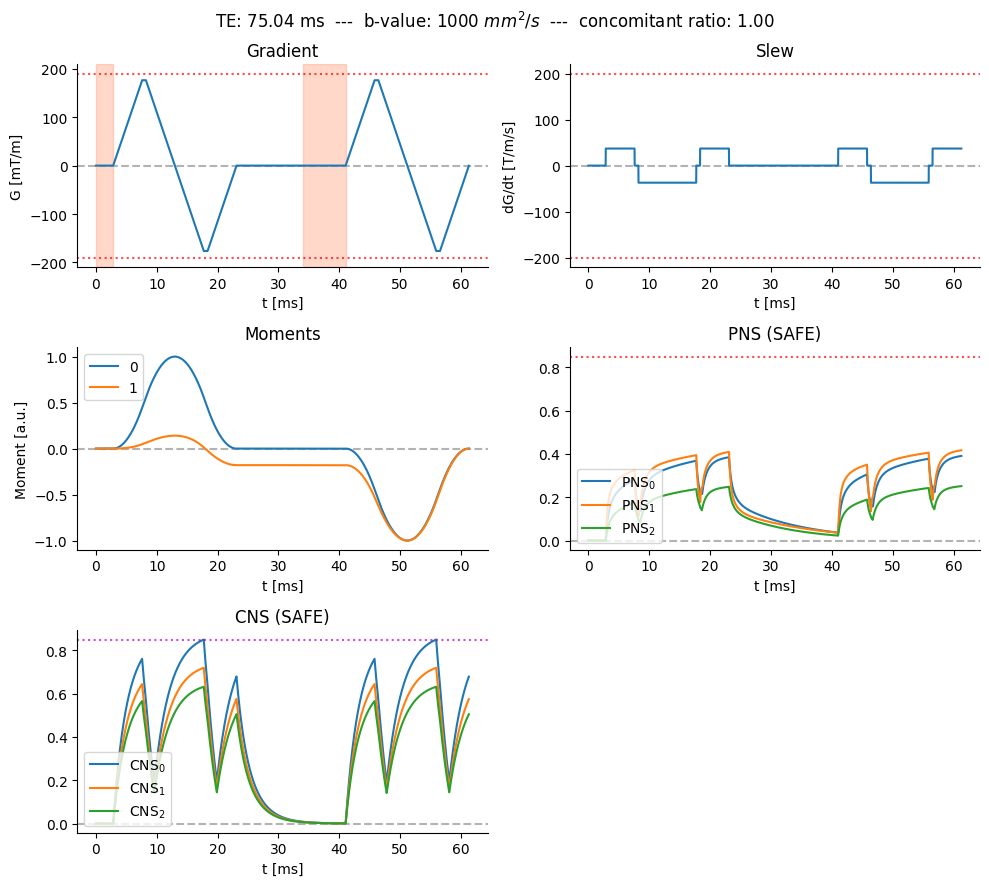

In [25]:
# Inherit base parameters; define some additional limits
trap_params = {**base_params,
          'smax': 200, 
          'cns_lim': 0.85,
          'pns_lim': 0.85, 'pns_params': safe,   
          'cns_params': safe_cardiac,
          'pns_idx': [0,1,2], 'cns_idx': [0,1,2]}

trap_params['dt'] = 10e-6 # we can use smaller dt for trapezoids

# define a trapezoid object 
trap_obj = GetMinTE_Trap(trap_params, 
                gmaxRange=[0.100, trap_params['gmax']], # range of gmax to search over
                smaxRange=  np.concatenate(([200], np.arange(120, 20, -2))),) # range of smax to search over

# run binary search to find minimum TE and corresponding gradient waveform
TE_trap, g_waveform_trap, t_array, bval_trap, timings_trap = trap_obj.compute_binary()

# plot the results
plot_diff(g_waveform_trap, trap_params['dt'], TE = TE_trap, params = trap_params, plot_pns=True, plot_cns=True, pns_params = safe,cns_params = safe_cardiac)

# Stim-CODE Diffusion-Encoding: Constant Threshold

starting TE search: 0.021, 0.09

Searching TE: 55.50 72.75 64.12 59.81 57.66 56.58 56.04 55.77 Done!


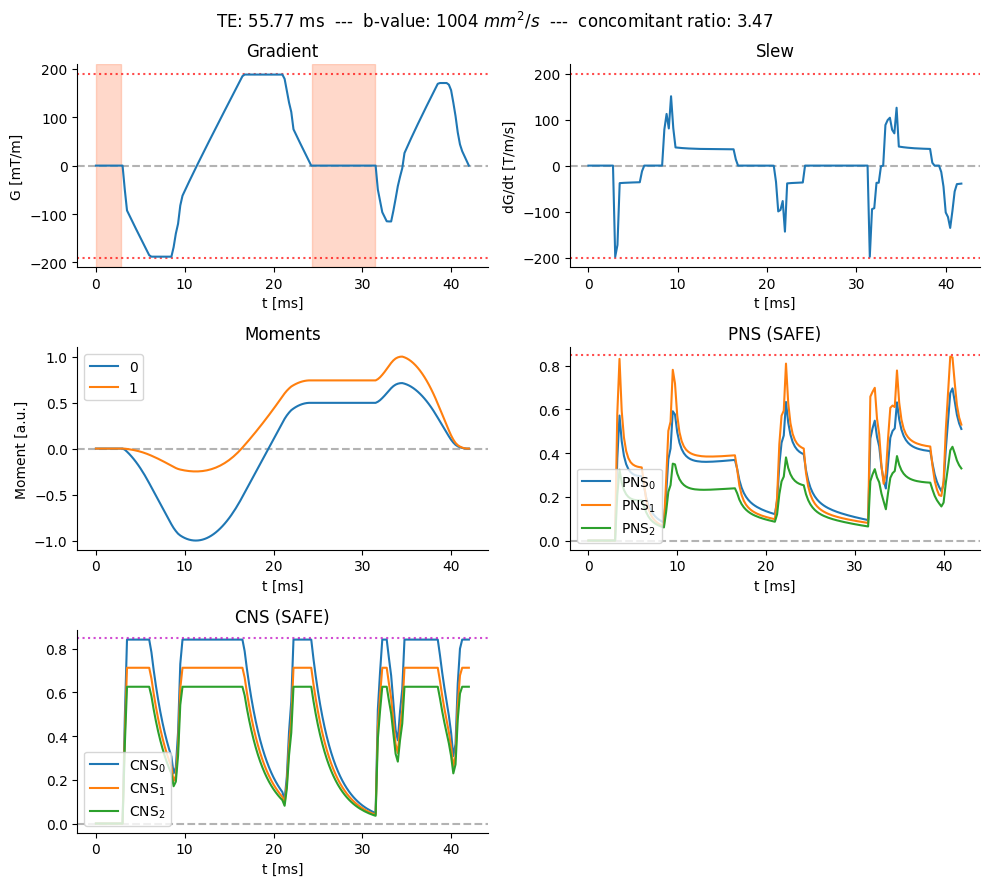

In [26]:
# Inherit base parameters; define some additional limits
params = {**base_params,
            'dt': 250e-6,  # Gradient waveform step size [s]
          'smax': 200, 
          'cns_lim': 0.85,
          'pns_lim': 0.85, 'pns_params': safe,   
          'cns_params': safe_cardiac,'pns_idx': [0,1,2], 'cns_idx': [0,1,2]}

# Call GrOpt to find optimal solution
TE, result = diff_min_TE_base(params,stop_dt = params['dt'],TE1= 90e-3)

if result is None:
    print("No solution found within the specified limits.")
else:
    # Plot some results
    plot_diff(result.X, result.dt, TE = TE, params = params, plot_pns=True, plot_cns=True, pns_params = safe,cns_params = safe_cardiac)

# Stim-CODE: Arbitrary Envelope Function
Define a vector instead of a constant threshold, but it is arbitrarily defined

starting TE search: 0.021, 0.09

Searching TE: 55.50 72.75 64.12 59.81 57.66 56.58 56.04 55.77 Done!


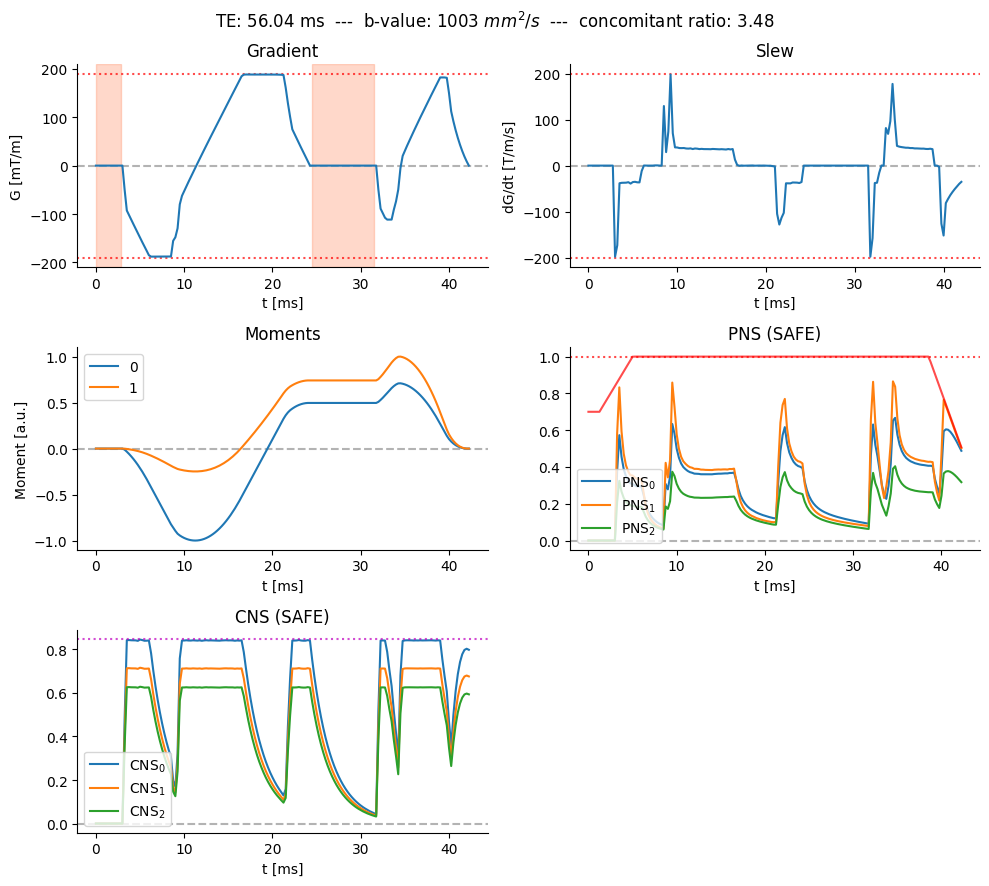

In [27]:
# Make an arbitrary envelope that ra
stim_vec = make_stim_envelope(params,TE = 90e-3, start_val = 0.7, end_val = 0.5, T_ramp = 7e-3)

# Inherit base parameters; define some additional limits
params = {**base_params,
           'dt': 250e-6,  # Gradient waveform step size [s]
          'smax': 200, 
          'cns_lim': 0.85,
          'pns_lim': stim_vec, 'pns_params': safe,   
          'cns_params': safe_cardiac,'pns_idx': [0,1,2], 'cns_idx': [0,1,2]}

# Call GrOpt to find optimal solution
TE, result = diff_min_TE_base(params,stop_dt = params['dt'],TE1= 90e-3)

if result is None:
    print("No solution found within the specified limits.")
else:
    # Plot some results
    plot_diff(result.X, result.dt, TE = TE, params = params, plot_pns=True, plot_cns=True, pns_params = safe,cns_params = safe_cardiac)

# Stim-CODE: Envelope Function based on Sequence 
Define a vector based on the gradient waveforms from other gradient events

starting TE search: 0.020900000000000002, 0.07

Searching TE: !45.45[2026-04-25 23:37:01.999] [error] Large values detected in Xhat at iteration 22. Stopping solver.
 57.73 51.59 54.66 53.12 53.89 54.27 54.08 Done!


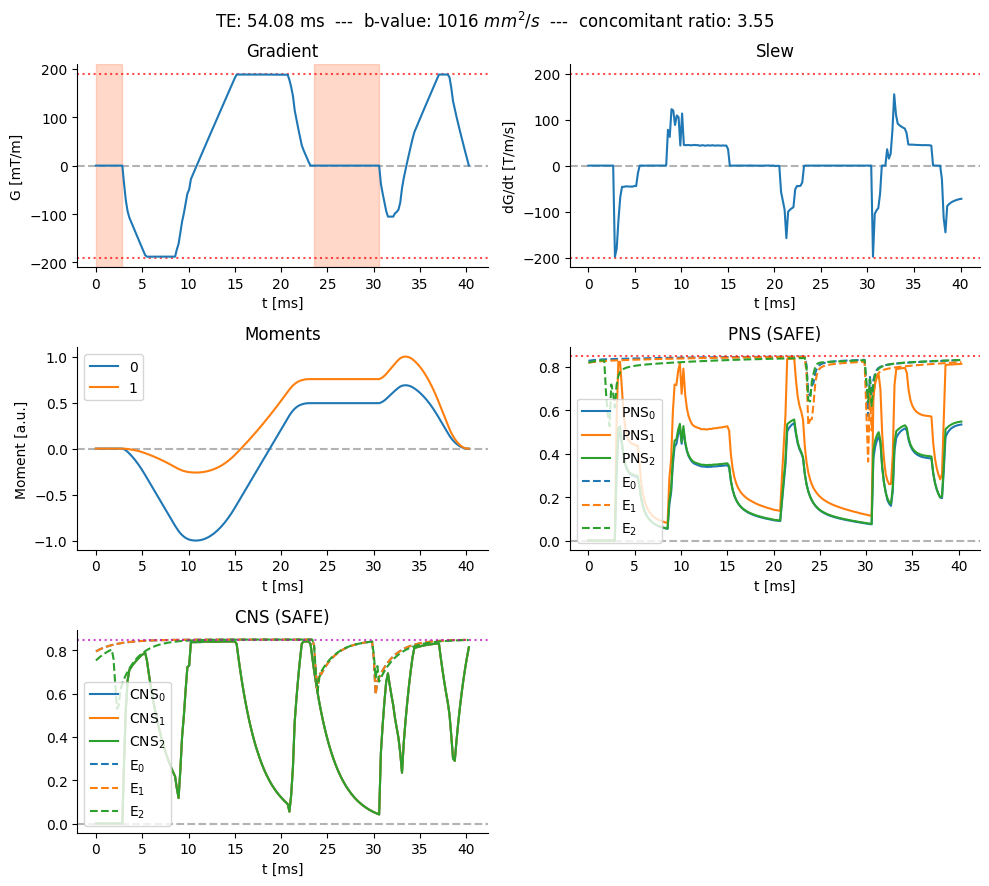

In [5]:
# currently designing envelope takes .mat files with waveforms and timings from pulseq in the future will design envelope based on dictionary
timings_file = 'diffusion_timing_parameters.mat' # timings in seconds 
waveforms_file = 'diffusion_timing_parameters_waveforms.mat' # right now units are in Hz/m for gradients in future will be mT/m or T/m

# to construct envelope in demo, you need the waveforms and timing parameters of a sequence 
# for this example, they are stored in the waveforms file, timings match the original timings

# Inherit base parameters; define some additional limits
params = {**base_params,
           'dt': 190e-6,  # Gradient waveform step size [s]
          'smax': 200, 
          'cns_lim': 0.85,
          'pns_lim': 0.85, 
          'pns_params': safe, 'cns_params': safe_cardiac,
          'pns_idx': [0,1,2], 'cns_idx': [0,1,2]}

# Call GrOpt to find optimal solution
TE, result = diff_min_TE_base(params,stop_dt = params['dt'],TE1= 70e-3, 
            timings_file=timings_file,  # envelope will be constructed based on timings
            waveforms_file=waveforms_file, # envelope constructed based on waveforms_file
            seq_repeats = 5) # number of sequence repeats for steady state envelope (if undefined, will do 5 repeat)


if result is None:
    print("No solution found within the specified limits.")
else:
    # Plot some results
    plot_diff(result.X, result.dt, TE = TE, params = params, plot_pns=True, plot_cns=True, 
              pns_params = safe,cns_params = safe_cardiac,
              timings_file=timings_file, waveforms_file=waveforms_file, seq_repeats = 5)